# Phase 4 — RT-DETR-L Implementation

Analysis of the trained RT-DETR-L model, compared against our own
YOLOv8n baseline (Phase 3). Note: the base paper does not include
RT-DETR results, so this comparison is against our own reproduction,
not the paper's numbers.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

with open(PROJECT_ROOT / "results" / "rtdetr" / "performance_report.json") as f:
    rtdetr_report = json.load(f)

with open(PROJECT_ROOT / "results" / "baseline_yolov8" / "performance_report.json") as f:
    yolov8_report = json.load(f)

rtdetr_report

{'model': 'RT-DETR-L',
 'paper_batch_size': 64,
 'actual_batch_size_used': 8,
 'batch_size_reduced_due_to_hardware': True,
 'attempt_log': [{'batch_size': 8,
   'status': 'success (manually stopped at epoch 61, plateaued since ~epoch 30, best checkpoint ~epoch 53)'}],
 'epochs': 200,
 'optimizer': 'Adam',
 'imgsz': 640,
 'parameters': 32816351,
 'GFLOPs': 109.91,
 'FPS': 37.63,
 'model_size_MB': 251.47,
 'speed_breakdown_ms': {'preprocess': 0.4807512822131125,
  'inference': 25.884448205276083,
  'loss': 0.000470256409010826,
  'postprocess': 0.20734923055920845},
 'mAP50': 0.9690475442516714,
 'mAP50_95': 0.6510501629248757,
 'precision': 0.9712679578760554,
 'recall': 0.9376888382536063,
 'epochs_actually_run': 61,
 'stopped_reason': 'manual stop after sustained plateau (patience threshold not yet formally met, but no meaningful improvement since ~epoch 30)'}

## Training curves

RT-DETR was trained across multiple resumed sessions (interrupted for
system restarts and a mid-training fix for NaN losses caused by AMP
instability in deformable attention). `results.csv`/`results.png`
reflect the cumulative record across all resumes from the final run.

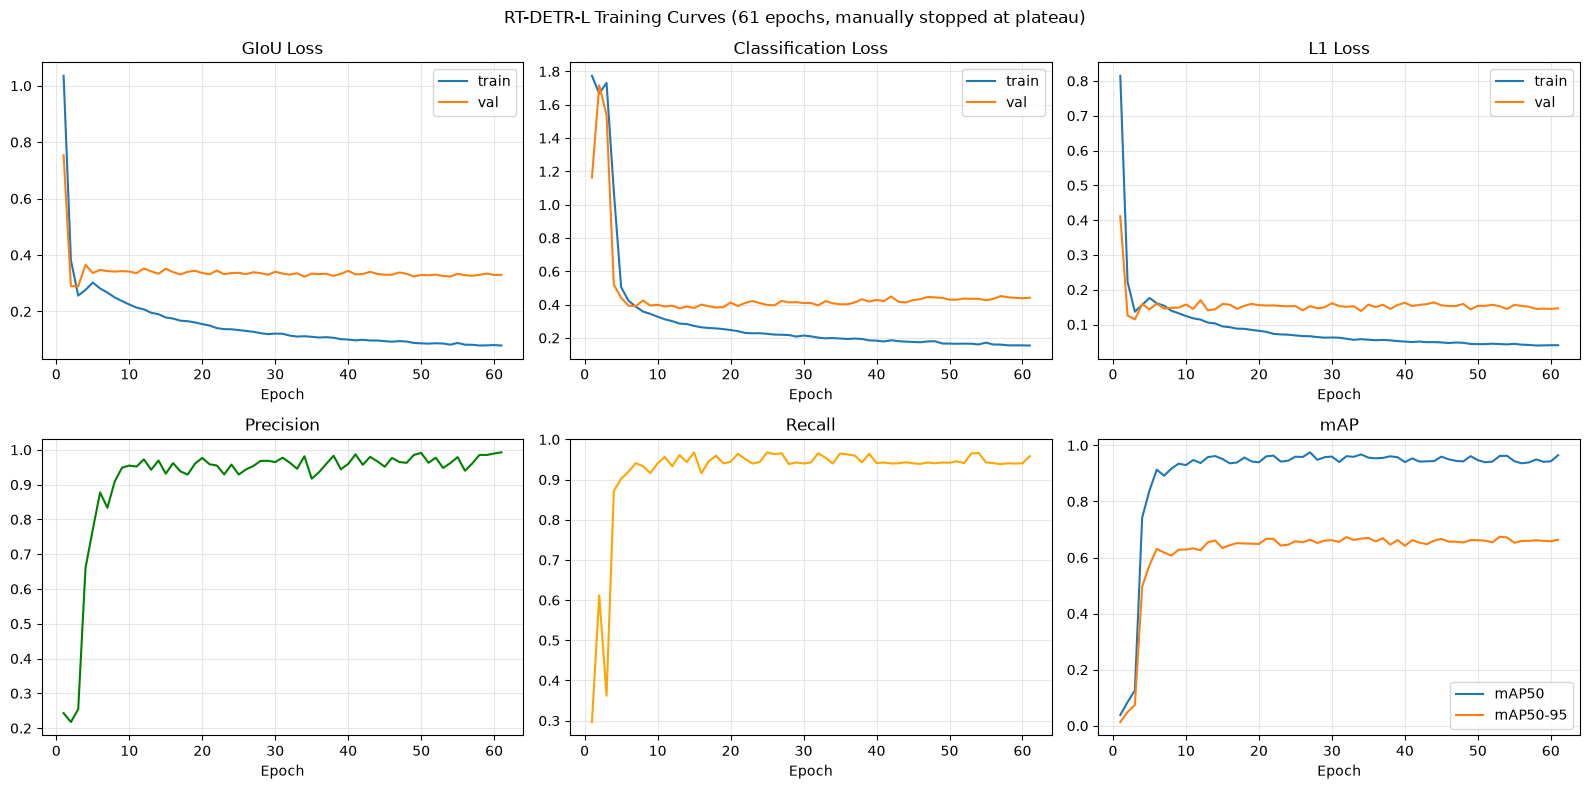

In [3]:
results_csv_path = PROJECT_ROOT / "results" / "rtdetr" / "run" / "results.csv"

if results_csv_path.exists():
    results_df = pd.read_csv(results_csv_path)
    results_df.columns = results_df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    axes[0, 0].plot(results_df["epoch"], results_df["train/giou_loss"], label="train")
    axes[0, 0].plot(results_df["epoch"], results_df["val/giou_loss"], label="val")
    axes[0, 0].set_title("GIoU Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(results_df["epoch"], results_df["train/cls_loss"], label="train")
    axes[0, 1].plot(results_df["epoch"], results_df["val/cls_loss"], label="val")
    axes[0, 1].set_title("Classification Loss")
    axes[0, 1].legend()

    axes[0, 2].plot(results_df["epoch"], results_df["train/l1_loss"], label="train")
    axes[0, 2].plot(results_df["epoch"], results_df["val/l1_loss"], label="val")
    axes[0, 2].set_title("L1 Loss")
    axes[0, 2].legend()

    axes[1, 0].plot(results_df["epoch"], results_df["metrics/precision(B)"], color="green")
    axes[1, 0].set_title("Precision")

    axes[1, 1].plot(results_df["epoch"], results_df["metrics/recall(B)"], color="orange")
    axes[1, 1].set_title("Recall")

    axes[1, 2].plot(results_df["epoch"], results_df["metrics/mAP50(B)"], label="mAP50")
    axes[1, 2].plot(results_df["epoch"], results_df["metrics/mAP50-95(B)"], label="mAP50-95")
    axes[1, 2].set_title("mAP")
    axes[1, 2].legend()

    for ax in axes.flatten():
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)

    plt.suptitle("RT-DETR-L Training Curves (61 epochs, manually stopped at plateau)")
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "report" / "figures" / "rtdetr_training_curves.png", dpi=150)
    plt.show()
else:
    print("results.csv not found -- check the path in results/rtdetr/run/")

## Training deviations from the paper's protocol

Documented for methodology transparency:

- **Learning rate**: reduced from the paper's `lr0=0.01` to `0.0001`
  for RT-DETR specifically. The paper's learning rate was tuned for
  YOLOv8's convolutional architecture; applying it unchanged to
  RT-DETR's deformable attention caused NaN losses around epoch 9
  under mixed precision. Lowering it 100x (rather than disabling AMP,
  which cost a 4x epoch-time slowdown) resolved this while preserving
  training speed.
- **Batch size**: reduced from the paper's 64 to 8, due to RT-DETR-L's
  much larger memory footprint (~33M params vs. YOLOv8n's ~3M) on our
  6GB GPU.
- **Early stopping**: training was manually stopped at epoch 61 after
  a sustained plateau from ~epoch 30 onward (best checkpoint by
  fitness score was ~epoch 53), rather than waiting for the formal
  `patience=30` condition to trigger, due to time constraints.

In [4]:
pd.DataFrame({
    "Deviation": ["Learning rate", "Batch size", "Epochs run"],
    "Paper protocol": ["0.01", "64", "200 (ceiling)"],
    "Actually used": ["0.0001", "8", "61 (manual stop, plateaued ~epoch 30)"],
    "Reason": [
        "NaN losses from deformable attention instability under paper's LR",
        "6GB VRAM insufficient for RT-DETR-L at paper's batch size",
        "Time constraint; no meaningful improvement after ~epoch 30",
    ],
})

,Deviation,Paper protocol,Actually used,Reason
0,Learning rate,0.01,0.0001,NaN losses from deformable attention instabili...
1,Batch size,64,8,6GB VRAM insufficient for RT-DETR-L at paper's...
2,Epochs run,200 (ceiling),"61 (manual stop, plateaued ~epoch 30)",Time constraint; no meaningful improvement aft...


## RT-DETR vs. our YOLOv8n baseline

In [5]:
comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP50", "mAP50-95", "FPS", "Parameters (M)", "GFLOPs", "Model size (MB)"],
    "YOLOv8n (ours)": [
        yolov8_report["precision"], yolov8_report["recall"],
        yolov8_report["mAP50"], yolov8_report["mAP50_95"],
        yolov8_report["FPS"], yolov8_report["parameters"] / 1e6,
        yolov8_report["GFLOPs"], yolov8_report["model_size_MB"],
    ],
    "RT-DETR-L (ours)": [
        rtdetr_report["precision"], rtdetr_report["recall"],
        rtdetr_report["mAP50"], rtdetr_report["mAP50_95"],
        rtdetr_report["FPS"], rtdetr_report["parameters"] / 1e6,
        rtdetr_report["GFLOPs"], rtdetr_report["model_size_MB"],
    ],
})
comparison["Difference (RT-DETR - YOLOv8)"] = (
    comparison["RT-DETR-L (ours)"] - comparison["YOLOv8n (ours)"]
)
comparison

,Metric,YOLOv8n (ours),RT-DETR-L (ours),Difference (RT-DETR - YOLOv8)
0,Precision,0.929301,0.971268,0.041967
1,Recall,0.831045,0.937689,0.106644
2,mAP50,0.890197,0.969048,0.078851
3,mAP50-95,0.554766,0.651050,0.096284
4,FPS,64.690000,37.630000,-27.060000
5,Parameters (M),3.011823,32.816351,29.804528
6,GFLOPs,8.200000,109.910000,101.710000
7,Model size (MB),5.960000,251.470000,245.510000


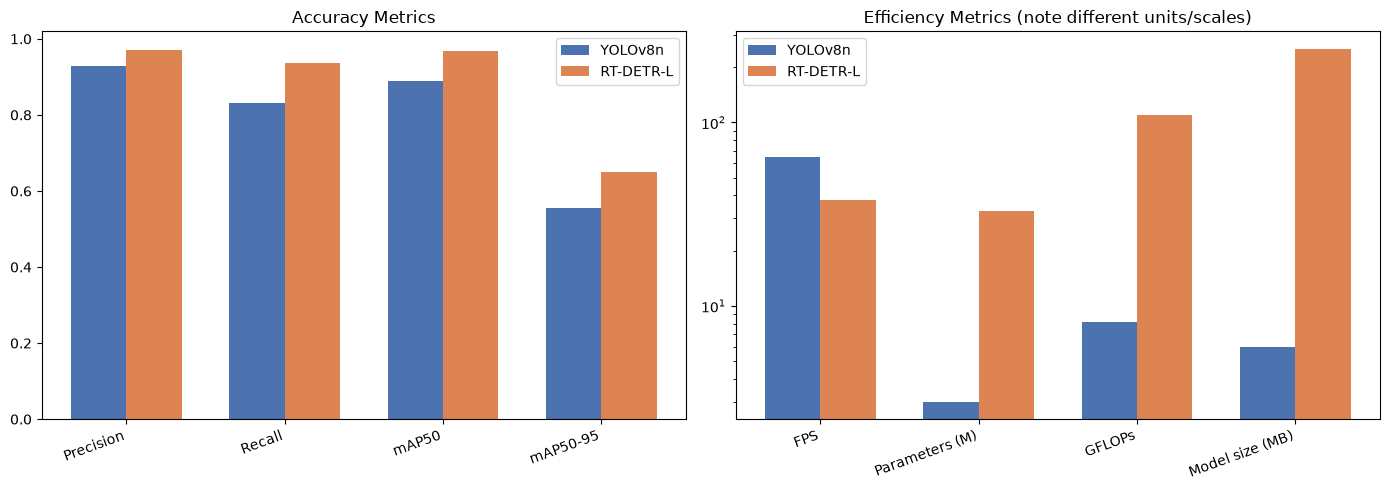

In [6]:
# Split into accuracy metrics (higher=better, similar scale) and
# efficiency metrics (very different scales) for readable charts
accuracy_metrics = comparison[comparison["Metric"].isin(
    ["Precision", "Recall", "mAP50", "mAP50-95"]
)]
efficiency_metrics = comparison[comparison["Metric"].isin(
    ["FPS", "Parameters (M)", "GFLOPs", "Model size (MB)"]
)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x1 = range(len(accuracy_metrics))
width = 0.35
axes[0].bar([i - width/2 for i in x1], accuracy_metrics["YOLOv8n (ours)"], width, label="YOLOv8n", color="#4C72B0")
axes[0].bar([i + width/2 for i in x1], accuracy_metrics["RT-DETR-L (ours)"], width, label="RT-DETR-L", color="#DD8452")
axes[0].set_xticks(list(x1))
axes[0].set_xticklabels(accuracy_metrics["Metric"], rotation=20, ha="right")
axes[0].set_title("Accuracy Metrics")
axes[0].legend()

x2 = range(len(efficiency_metrics))
axes[1].bar([i - width/2 for i in x2], efficiency_metrics["YOLOv8n (ours)"], width, label="YOLOv8n", color="#4C72B0")
axes[1].bar([i + width/2 for i in x2], efficiency_metrics["RT-DETR-L (ours)"], width, label="RT-DETR-L", color="#DD8452")
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(efficiency_metrics["Metric"], rotation=20, ha="right")
axes[1].set_title("Efficiency Metrics (note different units/scales)")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "rtdetr_vs_yolov8.png", dpi=150)
plt.show()

## Per-class performance

In [7]:
from ultralytics import RTDETR

model = RTDETR(str(PROJECT_ROOT / "results" / "rtdetr" / "run" / "weights" / "best.pt"))
data_yaml = PROJECT_ROOT / "data" / "processed" / "data.yaml"

val_results = model.val(data=str(data_yaml), split="test", workers=0)

per_class = pd.DataFrame({
    "Class": val_results.names.values(),
    "Precision": val_results.box.p,
    "Recall": val_results.box.r,
    "mAP50": val_results.box.ap50,
    "mAP50-95": val_results.box.ap,
})
per_class

Ultralytics 8.4.116  Python-3.14.2 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
rt-detr-l summary: 315 layers, 31,994,015 parameters, 0 gradients, 105.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1798.5226.7 MB/s, size: 1136.8 KB)
val: Scanning C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\data\processed\test\labels.cache... 195 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 195/195 26.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.0s/it 13.1s1.0s
                   all        195        293      0.971      0.938      0.969      0.651
              Cracking         47         59      0.951      0.987      0.967      0.683
        Layer_shifting         36         36      0.997          1      0.995      0.726
          Off_platform         10         10      0.962        0.9      0.972      0.619
             Stringing         45      

,Class,Precision,Recall,mAP50,mAP50-95
0,Cracking,0.951017,0.987258,0.967183,0.683018
1,Layer_shifting,0.996807,1.000000,0.995000,0.725547
2,Off_platform,0.962082,0.900000,0.971923,0.618837
3,Stringing,0.987699,0.902197,0.975767,0.757109
4,Warping,0.958736,0.898990,0.935365,0.470741


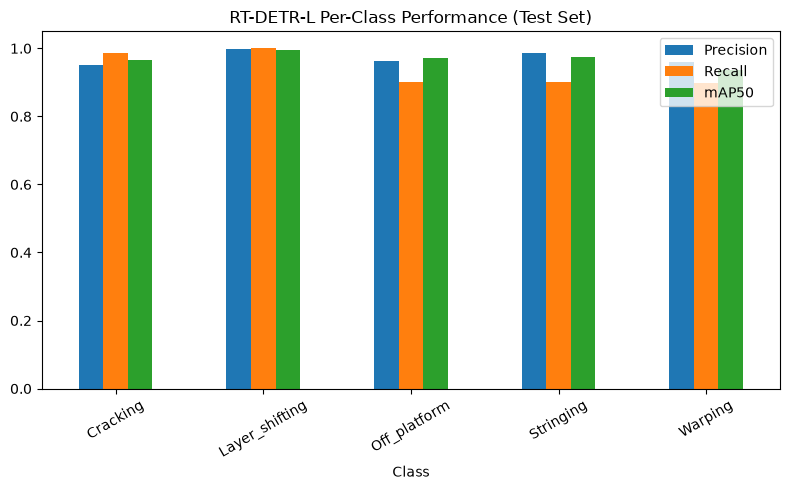

In [8]:
per_class.set_index("Class")[["Precision", "Recall", "mAP50"]].plot(
    kind="bar", figsize=(8, 5), rot=30
)
plt.title("RT-DETR-L Per-Class Performance (Test Set)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "rtdetr_per_class.png", dpi=150)
plt.show()

## Summary

- RT-DETR-L outperforms our YOLOv8n baseline on every accuracy metric
  (mAP50: 0.969 vs. 0.890; recall: 0.938 vs. 0.831), consistent with
  the expected benefit of global attention for defect localization.
- This came at a real cost: ~11x more parameters, ~13x more GFLOPs,
  ~42x larger model size, and roughly 42% lower FPS (37.6 vs. 64.7).
- Notably, RT-DETR reached this result in only 61 epochs (vs.
  YOLOv8's 151), despite each epoch taking substantially longer in
  wall-clock time due to the transformer decoder's compute cost.
- Real hardware constraints (6GB VRAM) required a much smaller batch
  size and a lower learning rate than the paper's protocol -- both
  documented above as legitimate, necessary deviations.
- This tradeoff -- higher accuracy vs. real-time deployability -- is
  the central theme to expand on in Phase 10 (Scientific Discussion).